#### Random Forest Classifier using GridSearchCV

It is a kind of supervised machine learning technique that works with n number of decision trees so as to improve the accuracy and the performance of the model.

GridSearchCV is one of the best optimized machine learning technique that goes through all possible combinations of hyper parameters and finds out the best hyperparameter that is suitable for a given machine learning model.

#### Aim of this Algorithm:--

1.  The main aim of this algorithm is to predict whether the Customer will purchase the product based on the Social_Networks_Ads details.

2.  We have also used Hyper Parameter tuning with GridSearchCV that will go through all posssible combinations of the hyper parameter and find out the optimal hyper parameter that will improve the accuracy of the model.


#### Importance of GridSerachCV

1.  It is an optimization technique used to improve the accuracy of machine learning model by going through all possible combinations of the hyperparameters and finding out the most optimal hyperparameter that can improe the accuracy of the model.

2.  This is a very time taking and time consuming process as it considers all possible combinations of the hyper parameters and takes a lot of time to find out the optimal hyper parameter.


#### Step 1: Import all the necessary libraries

In [1043]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split,    GridSearchCV,   StratifiedKFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.ensemble        import  RandomForestClassifier
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

#### Step 2:    Load the Dataset

In [1044]:
#### Load the dataset

df = pd.read_csv("Social_Network_Ads.csv")

In [1045]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


#### OBSERVATIONS:

1.  The above dataset explains about the details of all the customers and determines whther the customer will purchase the product or not based on the Social_Networks_Ads details.

2.  The independent eatures of the dataset are as follows :---

    (a.)    UserID ===============> ID of a particular user.

    (b.)    Gender ===============> Gender of the user.

    (c.)    Age    ================> Age of the user.

    (d.)    EstimatedSalary ========> Salary of the user.


3.  The dependent feature of the dataset is Purchased.

    (a.)  If Purchased = 0 ================> Customer will not purchased the product.

    (b.)  If Purchased = 1 ================> Customer will purchase the product.

#### Step 3: Perform  the Data Exploration

In [1046]:
#### get the top five rows of the dataset

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [1047]:
#### get the bottom five rows of the dataset

df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [1048]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 400


In [1049]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (400, 5)


In [1050]:
#### get the columns used in the dataset

df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [1051]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [1052]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


#### OBSERVATIONS:

1.  The above table explains about the descriptive statistical summary about each numerical columns used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1053]:
#### To check for any NULL records used in the dataset

df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [1054]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,User ID,Gender,Age,EstimatedSalary,Purchased


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [1055]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [1056]:
#### Remove the unnecessary columns "UserID" and "Gender" from the dataset

df.drop(columns=["User ID","Gender"],axis=1,inplace=True)

In [1057]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [1058]:
#### To again check for any NULL records used in the revised dataset

df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the revised dataset.

In [1059]:
#### To again check for the duplicate records used in the dataset

df[df.duplicated()]

,Age,EstimatedSalary,Purchased
23,45,22000,1
54,27,58000,0
74,32,18000,0
86,24,55000,0
94,29,83000,0
138,28,59000,0
150,26,15000,0
186,20,82000,0
192,29,43000,0
195,34,43000,0


#### OBSERVATIONS:

1.  There are some duplicate records in the dataset, so remove them.

In [1060]:
#### Remove the duplicate records from the dataset

df.drop_duplicates(inplace=True)

In [1061]:
#### To again check for the duplicate records used in the dataset

df[df.duplicated()]

,Age,EstimatedSalary,Purchased


#### OBSERVATIONS:

1.  There are now no duplicate records in the dataset.

In [1062]:
#### get the length of the revised dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 367


In [1063]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (367, 3)


#### OBSERVATIONS:

(i.)	The dataset contained two unnecessary columns, namely "User ID" and "Gender". These columns were removed from the dataset.

(ii.)	After removing the unnecessary columns, 33 duplicate records were identified in the dataset.

(iii.)	All duplicate records were removed to improve data quality and maintain data consistency.

(iv.)	The final dataset contains only unique records and has no missing (NULL) values.

#### Step 5:  Perform Exloratory Data Analysis

In [1064]:
#### display the data

df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [1065]:
#### get the correlation between all the numeric columns used in the dataset

df.corr()

,Age,EstimatedSalary,Purchased
Age,1.000000,0.167771,0.626164
EstimatedSalary,0.167771,1.000000,0.375624
Purchased,0.626164,0.375624,1.000000


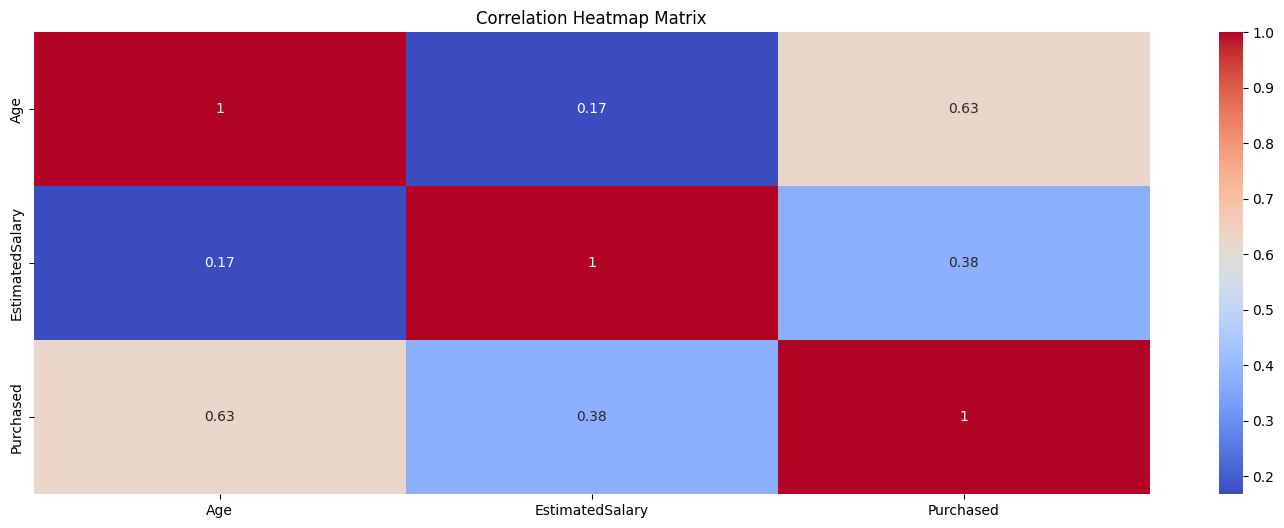

In [1066]:
#### get the graphical representation for the correlation between all the numeric columns used in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the graphical representation for the correlation between all the numeric columns used in the dataset


2.  There is a very high correlation between "Purchased" and "Age"

3.  The correlation between "Purchased" and "Age" > correlation between "EstimatedSalary" and "Purchased".

#### Step 6: Divide the dataset into independent and dependent variables

In [1067]:
#### independent variables

X = df.drop(columns='Purchased',axis=1)

In [1068]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [1069]:
#### dependent variables

Y = df['Purchased']

In [1070]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 367, dtype: int64

In [1071]:
len(Y)

367

#### Step 7: Divide the independent and dependent variables into training and testing data

In [1072]:
from sklearn.model_selection    import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1073]:
X_train

,Age,EstimatedSalary
162,37,33000
279,50,36000
389,48,35000
18,46,28000
170,21,88000
...,...,...
56,23,48000
48,30,135000
244,41,72000
9,35,65000


In [1074]:
X_test

,Age,EstimatedSalary
254,50,44000
131,33,31000
385,56,60000
65,24,58000
34,27,90000
...,...,...
377,42,53000
183,33,43000
1,35,20000
253,37,146000


In [1075]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (293, 2)
Shape of the input testing  data is: (74, 2)


In [1076]:
Y_train

162    0
279    1
389    1
18     1
170    0
      ..
56     0
48     1
244    0
9      0
155    0
Name: Purchased, Length: 293, dtype: int64

In [1077]:
Y_test

254    0
131    0
385    1
65     0
34     0
      ..
377    0
183    0
1      0
253    1
194    0
Name: Purchased, Length: 74, dtype: int64

In [1078]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (293,)
Shape of the output testing  data is: (74,)


#### OBSERVATIONS:

1.  There are a total of 367 records in the dataset.

2.  Out of 367 records, 293 records are the training data (80 % of the data is training)

3.  74 records are the testing data (20 % of the data are testing)

#### Step 8: Perform Hyper Parameter Tuning with GridSearchCV

In [1079]:
#### define the pipeline

from    sklearn.pipeline    import  Pipeline

#### create an object for Pipeline

pipeline = Pipeline([
    ("sc"           ,       StandardScaler())           ,
    ("rfc"          ,       RandomForestClassifier())
])

In [1080]:
#### define the param grid

param_grid = {
    "rfc__n_estimators"         :       [50,100,200]        ,
    "rfc__max_depth"            :       [5,10,20]           ,
    "rfc__min_samples_split"    :       [2,5,10]            ,
    "rfc__min_samples_leaf"     :       [1,2,4]             ,
    "rfc__criterion"            :       ["gini","entropy"]
}

In [1081]:
#### perform the Stratified K Fold Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [1082]:
#### create an object for GridSearchCV

grid = GridSearchCV(
    pipeline                                                ,
    param_grid          =           param_grid              ,
    cv                  =               cv                  ,
    scoring             =           'accuracy'              ,
    n_jobs              =               -1
)

In [1083]:
### using the object for GridSearchCV, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('rfc', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'rfc__criterion': ['gini', 'entropy'],
                         'rfc__max_depth': [5, 10, 20],
                         'rfc__min_samples_leaf': [1, 2, 4],
                         'rfc__min_samples_split': [2, 5, 10],
                         'rfc__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [1084]:
#### Obtain the best parameters and the estimator of the model

best_parameter = grid.best_params_

print("Best Parametets of the model is:", best_parameter)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parametets of the model is: {'rfc__criterion': 'gini', 'rfc__max_depth': 20, 'rfc__min_samples_leaf': 1, 'rfc__min_samples_split': 10, 'rfc__n_estimators': 200}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('rfc',
                 RandomForestClassifier(max_depth=20, min_samples_split=10,
                                        n_estimators=200))])


In [1085]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [1086]:
Y_pred_grid

array([1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0])

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.24324324324324
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[44  2]
 [ 3 25]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.94      0.96      0.95        46
           1       0.93      0.89      0.91        28

    accuracy                           0.93        74
   macro avg       0.93      0.92      0.93        74
weighted avg       0.93      0.93      0.93        74



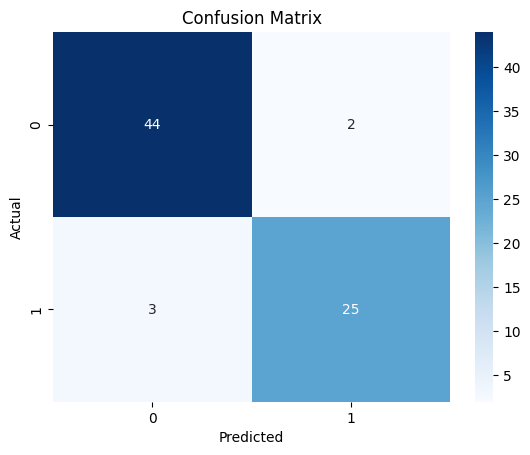

===============================Precision Score=======================================================
Precision score of the model is: 0.9259259259259259
===============================Recall Score=======================================================
Recall score of the model is: 0.8928571428571429
===============================F1 Score=======================================================
F1 score of the model is: 0.9090909090909091


In [1087]:
#### Evaluate the Classification Metrics ater perfroming hyper parameter tuning

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)


sns.heatmap(cmgrid, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_grid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_grid)

print("Recall score of the model is:", regrid)


print("===============================F1 Score=======================================================")

f1grid = f1_score(Y_test, Y_pred_grid)

print("F1 score of the model is:", f1grid)

#### OBSERVATIONS:

1.  The accuracy of Random Forest Classiier model using Social_Networks_Ads dataset is 93.24 

2.  This accuracy has been obtained by performing hyper parameter tuning the model using GridSearchCV operation.

In [1088]:
#### get the predicted probabilities of each output category

Y_pred_proba = best_estimator.predict_proba(X_test)[:,1]

In [1089]:
Y_pred_proba

array([6.39489626e-01, 9.15789474e-03, 8.35296343e-01, 0.00000000e+00,
       4.39962114e-01, 2.44318182e-03, 8.12286650e-01, 9.47367494e-01,
       1.36953248e-01, 2.19702381e-02, 1.42488038e-02, 9.14285714e-03,
       9.15501681e-01, 2.54875957e-02, 1.66666667e-03, 9.68750000e-03,
       0.00000000e+00, 2.13141585e-01, 8.84826092e-01, 8.82786307e-01,
       1.42488038e-02, 7.79790045e-01, 4.72737857e-01, 9.39398853e-01,
       7.09029289e-01, 8.88382739e-01, 9.65183846e-01, 7.69438948e-01,
       0.00000000e+00, 0.00000000e+00, 6.69642857e-04, 5.00000000e-04,
       1.42488038e-02, 2.29133004e-01, 1.95081169e-02, 9.27083333e-03,
       9.91063437e-01, 5.00000000e-04, 0.00000000e+00, 8.96251681e-01,
       2.64520202e-03, 3.18181818e-03, 3.00000000e-03, 4.27159699e-02,
       3.15291372e-01, 5.93750000e-03, 8.13814595e-02, 6.95020771e-01,
       3.75000000e-03, 8.85671127e-01, 5.77711894e-01, 1.07954545e-03,
       1.40795455e-02, 9.26972234e-01, 2.88209291e-02, 5.93750000e-03,
      

In [1090]:
#### Calculate the roc auc score of the model

rocaucscore = roc_auc_score(Y_test, Y_pred_proba)

print("ROC AUC Score of the model is:", rocaucscore)

ROC AUC Score of the model is: 0.9782608695652174


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical value that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.982 explains that the model has 98.2 % of the ability to determine correctly whether the customer has purchased the product or not based on Social_Networks_Ads dataset.

False Positive Rate is: [0.         0.         0.         0.02173913 0.02173913 0.04347826
 0.04347826 0.13043478 0.13043478 0.34782609 0.41304348 0.54347826
 0.58695652 0.7826087  0.86956522 1.        ]
True Positive Rate is: [0.         0.03571429 0.42857143 0.42857143 0.85714286 0.85714286
 0.92857143 0.92857143 1.         1.         1.         1.
 1.         1.         1.         1.        ]


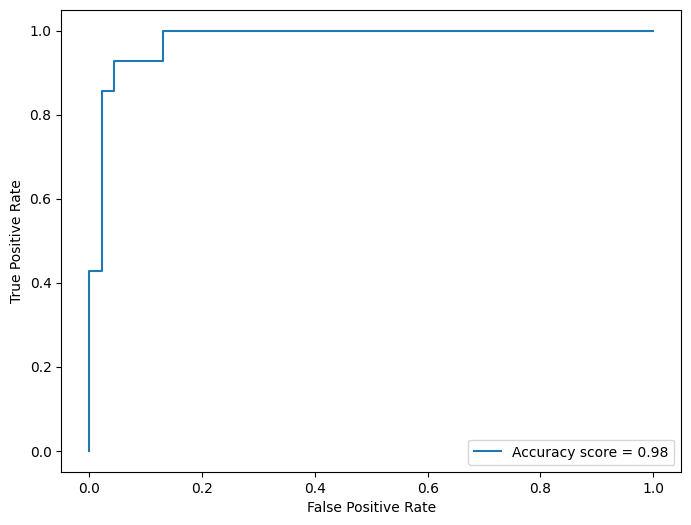

In [1091]:
#### perform the ROC Curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

print("False Positive Rate is:", fpr)

print("True Positive Rate is:", tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"Accuracy score = {rocaucscore:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### Step 9: Predict whether the customer will purchase the product or not based on the sample data

In [1092]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [1093]:
X.iloc[[35]]

,Age,EstimatedSalary
36,33,28000


In [1094]:
df.iloc[[35]]

,Age,EstimatedSalary,Purchased
36,33,28000,0


In [1095]:
#### define the sample data

sample = X.iloc[[35]]

print(sample)

#### perform the predictions based on the sample data

prediction = best_estimator.predict(sample)

print(prediction)

if(prediction[0] == 1):
    print("Customer has purchased the Social Netwoks Ads (1)")
else:
    print("Customer has not purchased the Social Netwoks Ads (0)")

    Age  EstimatedSalary
36   33            28000
[0]
Customer has not purchased the Social Netwoks Ads (0)


#### Step 10: Visualizing the Imporatant Features after performing Hyper Parameter Tuning

[0.52949971 0.47050029]
[0 1]
Index(['Age', 'EstimatedSalary'], dtype='object')


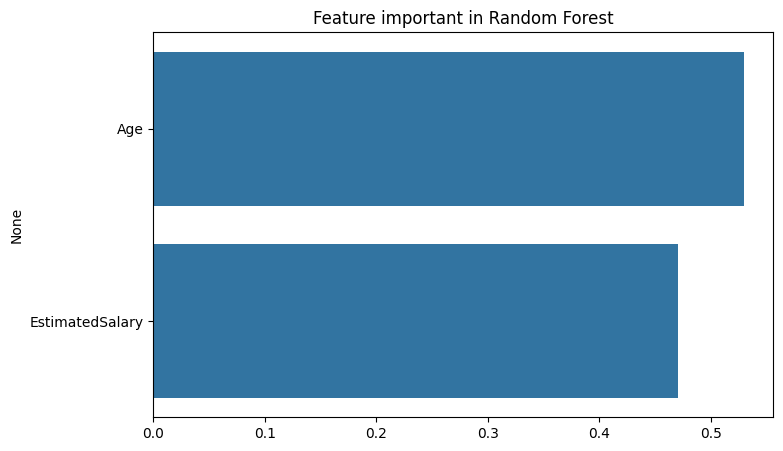

In [1096]:
#### extract all the important features from the dataset

ran_model = best_estimator.named_steps['rfc']

features = ran_model.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()

#### OBSERVATIONS:

1.  From the above graph, we can see that Age has more eature importance than EstimatedSalary column.

2.  So, Age should be given more importance than EstimatedSalary.